In [43]:
	
import corneto as cn
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

import warnings

from corneto.methods.metabolism import evaluate_gpr_expression
from corneto._data import Data
from corneto.methods.future.imat import MultiSampleIMAT
sys.path.append(os.path.abspath('..'))

import Functions as custom

import gemsembler
from cobra.io import read_sbml_model
from gemsembler.downstream import pathway_of_interest

# Changing the media for this model

load the curated model from Elena

In [44]:
model = read_sbml_model("/scratch/rebernig/VR002_Model_Analysis/Output/Curated_Models_Elena/B.Uniformis/Confidence_Levels_Biomass/curated.xml")

Load the media which I have created and exchange it 

In [45]:
LB_minus_O2_media = pd.read_csv("/scratch/rebernig/VR002_Model_Analysis/Scripts/Elenas_models/1_Media_and_Biomass_change/LB_minus_O2_media.csv", index_col=0).squeeze().to_dict()

In [46]:
med_mod = {}
for e in model.exchanges:
    if (
        list(e.metabolites.keys())[0].id
        in LB_minus_O2_media
    ):
        med_mod.update({e.id: LB_minus_O2_media[list(e.metabolites.keys())[0].id]})
    else:
        med_mod.update({e.id: 0})
old_medium = model.medium
model.medium = med_mod
model.reactions.ATPM.lower_bound=5.54
res = model.optimize()
res

,fluxes,reduced_costs
FBA2,0.000000,0.000000e+00
PYK,6.931078,9.992007e-16
EAR80x,3.717929,-2.220446e-16
FGFT,-4.020507,-2.220446e-16
OAADC,0.000000,-7.773698e-02
...,...,...
PGPP140pp,0.000000,-2.220446e-16
FACOAL140t2pp,0.000000,6.661338e-16
PLIPA1G140pp,0.000000,2.220446e-16
2AGPG140tipp,0.000000,0.000000e+00


Because I have to provide my model now in a different way, I will reload it with cn.io.import_cobra_model and call it G

In [47]:
G = cn.io.cobra_model_to_graph(model)
df = pd.read_csv("/scratch/rebernig/VR002_Model_Analysis/Output/Data_cleaning/Filtered_BU/filtered_BU.csv")
metadata = pd.read_csv("/scratch/rebernig/VR002_Model_Analysis/Data/Transcriptomics_Data_Juan/Buniformis/Buniformis_metadata.csv")

Change the name of the first column from "Name" to "gene", otherwise not working for CORNETO 

In [48]:
df = df.rename(columns={"Name": "gene"})

In [49]:
print(df.columns)
print(metadata.columns)

Index(['gene', 'sample1', 'sample5', 'sample9', 'sample13', 'sample16',
       'sample19', 'sample45', 'sample46', 'sample85', 'sample15', 'sample18',
       'sample21'],
      dtype='object')
Index(['Sample_ID', 'Condition'], dtype='object')


In [50]:
# 1. Average replicates by condition
dataset = custom.average_expression_by_condition(df, metadata)
dataset.to_csv("/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Average_Expression/Buniformis")


In [51]:
# 2. Discretize PER CONDITION
from corneto._data import Data, Sample, Feature

samples_data = {}
edge_ids = list(G.get_attr_from_edges("id"))

for cond in dataset.columns[1:]:
    expr_vals = dataset[cond]
    _, thresholds = pd.qcut(expr_vals, q=3, retbins=True, labels=['low','neutral','high'])

    scores = pd.Series(0, index=dataset['gene'])
    high_mask = expr_vals >= thresholds[2]
    low_mask  = expr_vals <= thresholds[1]
    scores.iloc[high_mask.to_numpy()] = 1
    scores.iloc[low_mask.to_numpy()]  = -1

    gene_score = dict(zip(dataset['gene'], scores))
    rxn_scores = evaluate_gpr_expression(G.get_attr_from_edges("GPR"), gene_score)
    rxn_scores = np.nan_to_num(rxn_scores, nan=0.0)

    # Build a list of Feature objects for this condition
    features_list = [
        Feature(id=edge_id, value=score, mapping="edge")
        for edge_id, score in zip(edge_ids, rxn_scores)
    ]

    samples_data[cond] = Sample(features_list)

data = Data(samples_data)




Showing how the Discretization is done

In [52]:

import seaborn as sns

def plot_quantile_discretization(dataset, condition, log2p1=True, q=3, kde=True, bins=50, savepath=None):
    """
    Plot distribution of expression values for one condition with quantile cutoffs.
    
    dataset: DataFrame with ['gene', condition1, condition2, ...]
    condition: str, column name to plot
    savepath: optional, full file path where the plot should be saved (e.g. "out/condA.png")
    """
    # 1) get expression values
    vals = pd.to_numeric(dataset[condition], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if vals.empty:
        raise ValueError(f"No numeric values found for condition '{condition}'.")

    # 2) compute quantile thresholds
    qs = [i/q for i in range(1, q)]  
    tvals = vals.quantile(qs).values  
    t1, t2 = tvals[0], tvals[-1] if len(tvals) > 1 else (tvals[0], tvals[0])

    # 3) masks
    low_mask  = vals <= t1
    high_mask = vals >= t2
    neut_mask = ~(low_mask | high_mask)

    # 4) transform for plotting
    def tx(x): return np.log2(x + 1) if log2p1 else x
    plot_vals = tx(vals)
    t1p, t2p = tx(t1), tx(t2)

    # 5) plotting
    fig, ax = plt.subplots(figsize=(7,5))
    sns.histplot(plot_vals, bins=bins, stat="density", kde=kde, ax=ax, alpha=0.5)

    # quantile lines
    ax.axvline(t1p, ls='--', lw=1.5, color='k', label='1/3 quantile')
    ax.axvline(t2p, ls='--', lw=1.5, color='k', label='2/3 quantile')


    ax.set_xlabel(f"{condition} (log2(TPM+1))" if log2p1 else f"{condition} (TPM)")
    ax.set_ylabel("Density")
    ax.set_title(f"Discretization for '{condition}' (q={q})")

    # save if requested
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.tight_layout()
        plt.savefig(savepath, dpi=300)
        print(f"✅ Figure saved to {savepath}")

    plt.show()

    return {"t1": float(t1), "t2": float(t2), 
            "n_low": int(low_mask.sum()), 
            "n_neutral": int(neut_mask.sum()), 
            "n_high": int(high_mask.sum())}

✅ Figure saved to /scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Discretization_Blot/B.uniformis.png


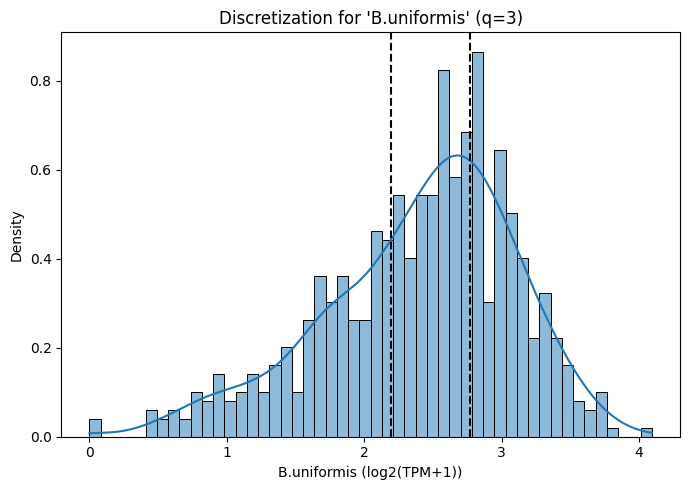

{'t1': 3.5848044926373803,
 't2': 5.807763904503917,
 'n_low': 203,
 'n_neutral': 201,
 'n_high': 203}

In [53]:
plot_quantile_discretization(
    dataset,
    condition="B.uniformis",
    savepath="/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Discretization_Blot/B.uniformis.png"
)


In [54]:
print(dataset.columns)

Index(['gene', 'B.uniformis', 'B.uniformis + BTheta', 'Com21',
       'P.vulgatus + Buniformis'],
      dtype='object')


## Running iMAT

In [55]:
# 3. Build Data object for MultiSampleIMAT
# iMAT hyperparams
# 4. Run iMAT
m = MultiSampleIMAT(lambda_reg=1, eps=1e-2, use_bigm_constraints=True)
preprocessed_data = m.preprocess(G, data)
P = m.build(preprocessed_data[0], preprocessed_data[1])
P.solve(solver="glpk", verbosity=0)


Problem(Minimize(Expression(AFFINE, UNKNOWN, ())), [Inequality(Constant(CONSTANT, UNKNOWN, (984, 4))), Inequality(Variable((984, 4), _flow)), Equality(Expression(AFFINE, UNKNOWN, (803, 4)), Constant(CONSTANT, ZERO, ())), Inequality(Expression(AFFINE, UNKNOWN, (984, 4))), Inequality(Variable((984, 4), _flow)), Inequality(Expression(AFFINE, NONNEGATIVE, (984, 4))), Equality(Expression(AFFINE, NONNEGATIVE, (44, 4)), Constant(CONSTANT, ZERO, ())), Equality(Expression(AFFINE, NONNEGATIVE, (2400, 4)), Constant(CONSTANT, ZERO, ())), Inequality(Expression(AFFINE, UNKNOWN, (984, 4))), Inequality(Variable((984, 4), _flow)), Inequality(Expression(AFFINE, NONNEGATIVE, (984, 4))), Inequality(Expression(AFFINE, NONNEGATIVE, (984,))), Inequality(Variable((984,), edge_has_flux_OR, boolean=True))])

The iMAT algorithm produces condition-specific metabolic subnetworks by integrating gene expression data with the genome-scale metabolic model.
The primary output is a reduced, context-specific model in which reactions are classified as active or inactive based on transcriptional evidence and network feasibility.
In addition, iMAT yields a feasible flux distribution that satisfies mass-balance and activity constraints, providing one possible steady-state flux configuration within the predicted active network.

In [56]:
# Extract number of samples
sample_names = list(data.samples.keys())
n_samples = len(sample_names)

# ✅ No need to drop any objectives — one per sample
P_objectives = P.objectives


# ✅ Compute condition scores (just take the corresponding objective)
condition_scores = {
    s_name: P_objectives[s_idx].value
    for s_idx, s_name in enumerate(sample_names)
}

## Post iMAT


Flux Extraction


In [57]:
reaction_ids = G.get_attr_from_edges("id")
flux_matrix = np.array(P.expr.flow.value)

# ✅ Each column corresponds directly to one sample
df_fluxes = pd.DataFrame(
    flux_matrix,
    index=reaction_ids,
    columns=sample_names
)
df_fluxes.to_csv("/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Flux/lambda1/Buniformis_flux")

# Min-Max Scaling 
for better comparison we Min-Max scaled the data, to see better the variability between the conditions

In [58]:
def minmax_scale_rows_neg1_to_1(df):
    row_absmax = df.abs().max(axis=1).replace(0, pd.NA)
    scaled = df.div(row_absmax, axis=0)  # Broadcast divide per row
    return scaled

df_scaled = minmax_scale_rows_neg1_to_1(df_fluxes).replace(pd.NA,0)


/tmp/ipykernel_5916/2614762912.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_scaled = minmax_scale_rows_neg1_to_1(df_fluxes).replace(pd.NA,0)


In [59]:
df_scaled

,B.uniformis,B.uniformis + BTheta,Com21,P.vulgatus + Buniformis
FBA2,0.000000,0.000000,0.0,0.00000
PYK,0.000508,0.887173,1.0,0.95723
EAR80x,0.000000,0.000000,0.0,0.00000
FGFT,0.000000,0.000000,0.0,0.00000
OAADC,-0.000000,1.000000,1.0,1.00000
...,...,...,...,...
PGPP140pp,0.000000,0.000000,0.0,0.00000
FACOAL140t2pp,0.000000,0.000000,0.0,0.00000
PLIPA1G140pp,0.000000,0.000000,0.0,0.00000
2AGPG140tipp,0.000000,0.000000,0.0,0.00000


In [60]:
df_scaled.to_csv('/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Flux/lambda0/Bunifromis_df_scaled')

Remove all Reaction where flux values are 0 for all condititions

In [61]:
# Remove rows where all values are 0
df_scaled_nonzero = df_scaled[(df_scaled != 0).any(axis=1)]

print(f"Before: {df_scaled.shape[0]} reactions")
print(f"After: {df_scaled_nonzero.shape[0]} reactions")
df_scaled_nonzero

Before: 984 reactions
After: 246 reactions


,B.uniformis,B.uniformis + BTheta,Com21,P.vulgatus + Buniformis
PYK,0.000508,0.887173,1.000000,0.957230
OAADC,-0.000000,1.000000,1.000000,1.000000
GHMT2r,1.000000,0.231369,0.970313,0.993385
PSP_L,1.000000,1.000000,1.000000,1.000000
ADSS,1.000000,1.000000,0.666667,1.000000
...,...,...,...,...
ILEt4,-1.000000,-1.000000,-1.000000,-1.000000
VALt4,-0.998915,-0.148365,-0.991170,-1.000000
PPAt6,0.680591,1.000000,0.766823,0.673029
TYRt2r,-1.000000,-0.500000,-1.000000,-0.500000


Next we calculate the variablity of conditions per flux. Only the 50 highest variablitiys are taken

In [62]:
# Calculate row variance
row_var = df_scaled_nonzero.var(axis=1)

# Keep top 50 most variable
df_top_var = df_scaled_nonzero.loc[row_var.sort_values(ascending=False).head(50).index]

df_top_var

,B.uniformis,B.uniformis + BTheta,Com21,P.vulgatus + Buniformis
G6PBDH,1.000000,-0.999910,-9.999100e-01,-0.008992
G6PDH2r,-0.999900,1.000000,1.000000e+00,0.009082
ALATA_L,-1.000000,-0.999480,2.518211e-03,-0.000010
ALAD_L,1.000000,0.999480,-2.518211e-03,0.000010
LDH_D,-1.000000,0.000000,0.000000e+00,-1.000000
LDH_D2,1.000000,0.000000,0.000000e+00,1.000000
NTPP2,-0.000000,-0.000000,1.000000e+00,1.000000
PPND2,0.000000,-0.000000,1.000000e+00,1.000000
HSDxi,0.000000,0.002451,1.000000e+00,1.000000
HSDy,-0.000010,-0.002461,-1.000000e+00,-1.000000


CLustered Heatmap

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

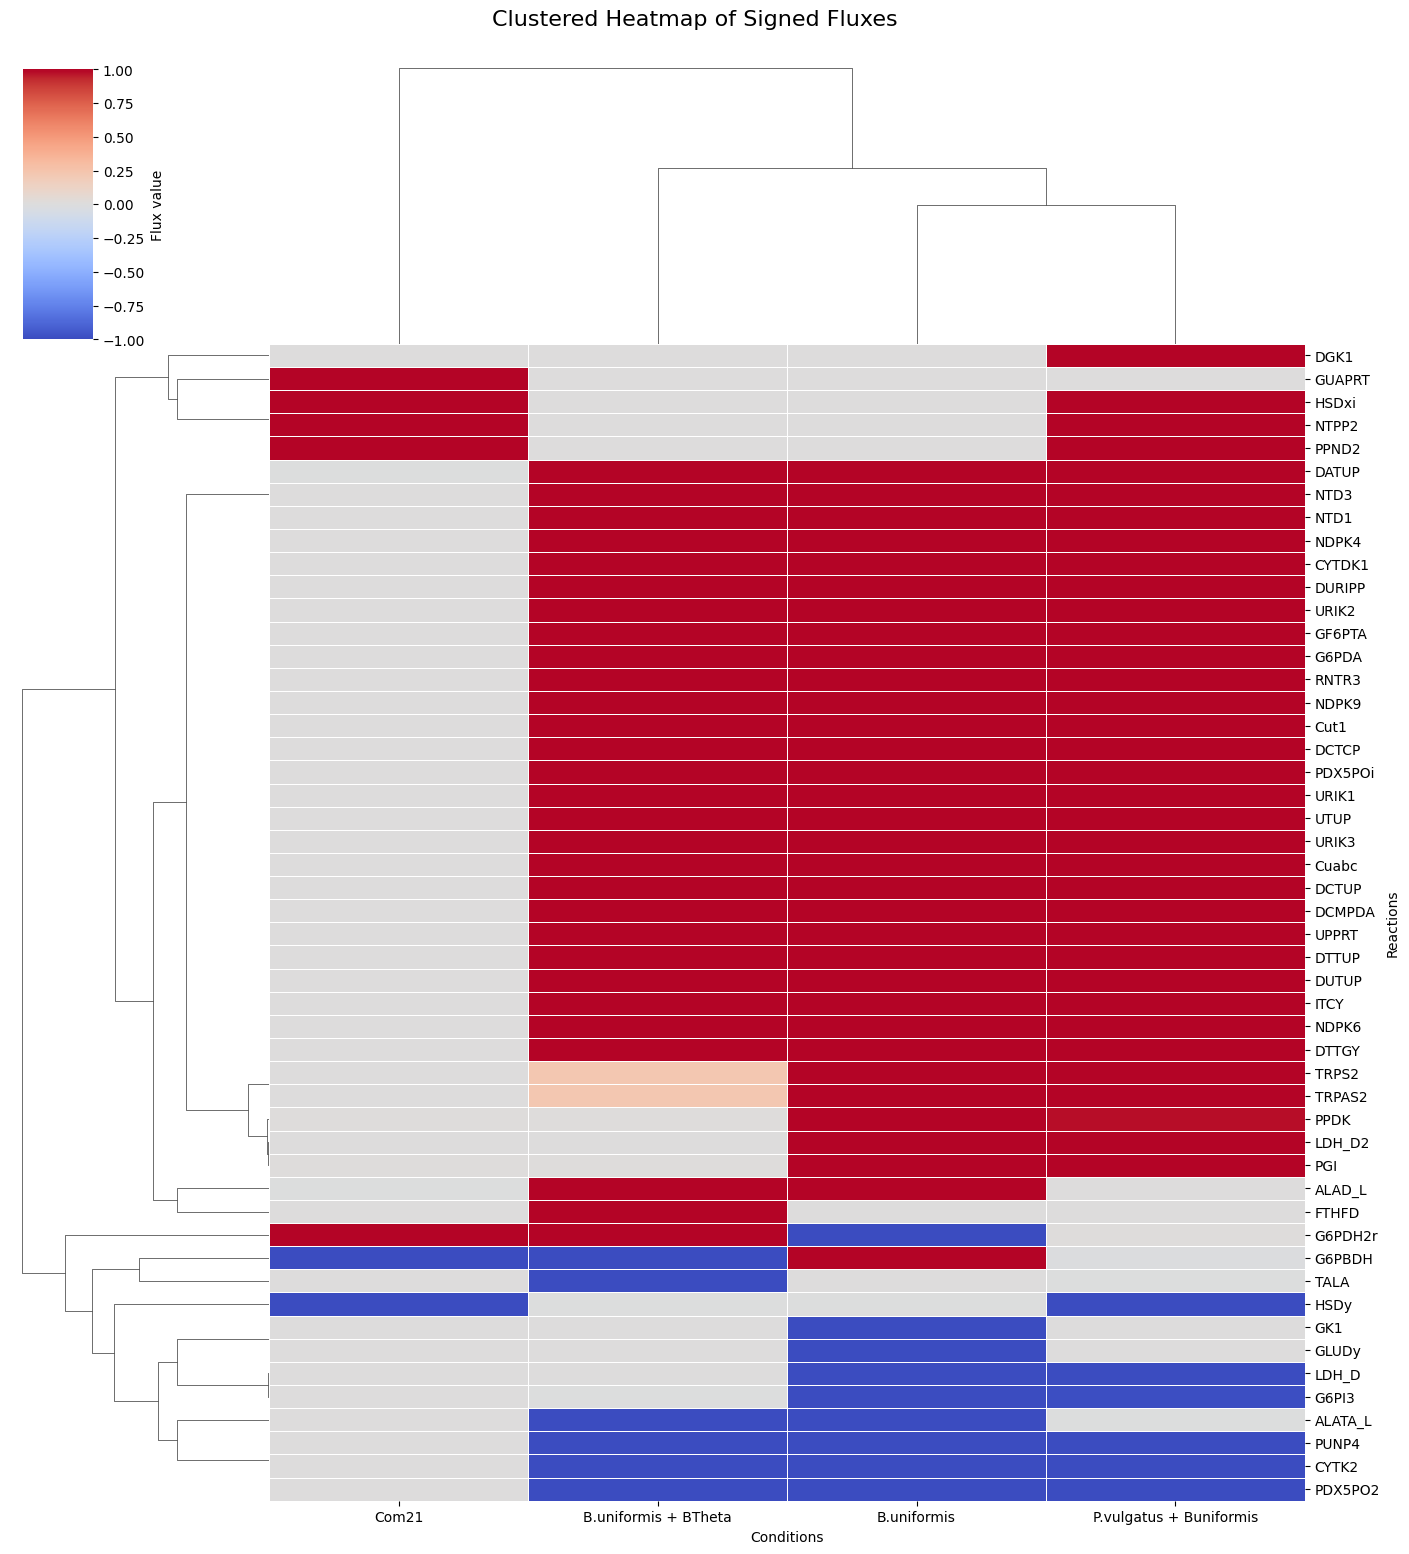

In [64]:
# 2. Create a clustered heatmap
g = sns.clustermap(
    df_top_var,
    cmap="coolwarm",         # blue=negative, white=zero, red=positive
    center=0,                # zero will be white
    figsize=(14, 15),
    linewidths=0.5,
    cbar_kws={"label": "Flux value"}
)

# 3. Label axes
g.ax_heatmap.set_xlabel("Conditions")
g.ax_heatmap.set_ylabel("Reactions")

plt.suptitle("Clustered Heatmap of Signed Fluxes", y=1.02, fontsize=16)
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Flux/lambda1/Buniformis_reaction_heatmap")



# PCA-Test 
Looking at the clsutering

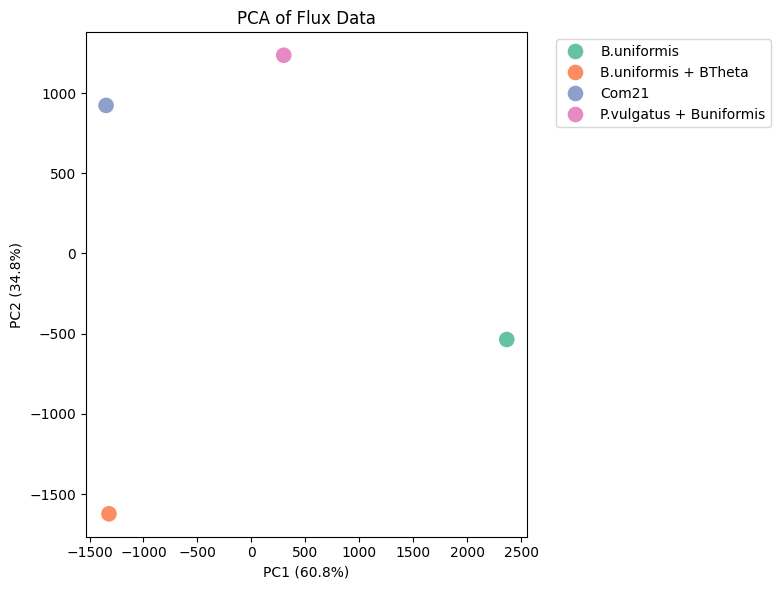

In [65]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Transpose so PCA runs on reactions as features
df_fluxes_T = df_fluxes.T 

# Run PCA
pca = PCA(n_components=2)
pc = pca.fit_transform(df_fluxes_T)

# Make dataframe for plotting
pca_df = pd.DataFrame(pc, columns=['PC1', 'PC2'], index=df_fluxes_T.index)
pca_df['Condition'] = pca_df.index  # since your index = condition names

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Condition', s=150, palette="Set2")
plt.title('PCA of Flux Data')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Flux/lambda1/Buniformis_PCA_2")
plt.show()

# Differntial Expression , vulcano plot
Because we can only measure the difference and not the p-value its not a tipical vulcano plot 

Using baseline condition: B.uniformis
Plotting: B.uniformis + BTheta


/home/rebernig/.conda/envs/cornetto/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log2
  result = func(self.values, **kwargs)


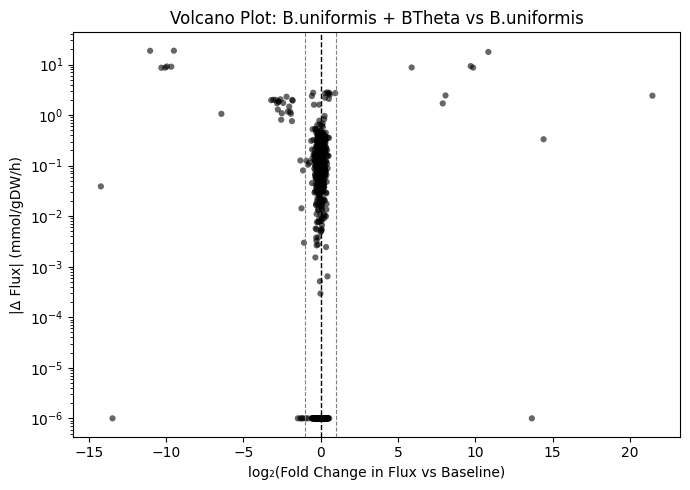

Plotting: Com21


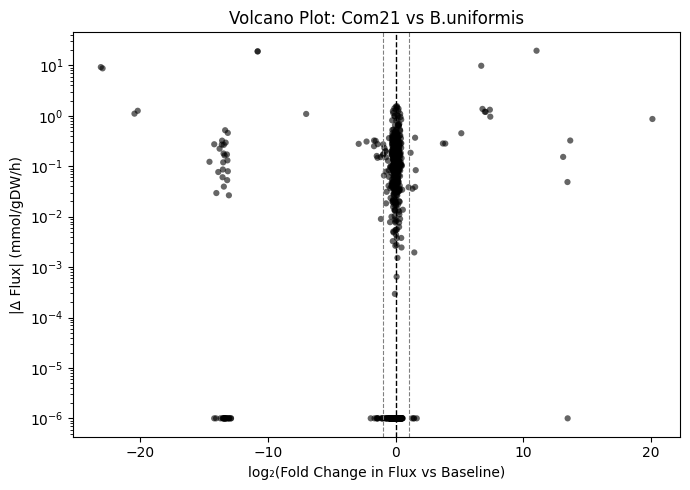

Plotting: P.vulgatus + Buniformis


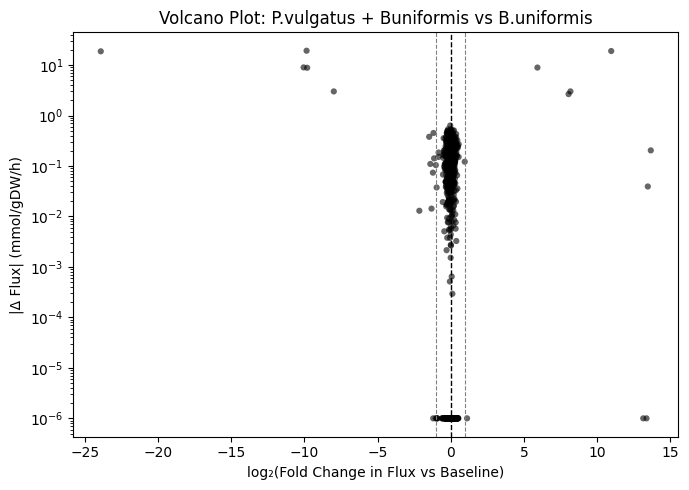

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Baseline condition
baseline = "B.uniformis"
print(f"Using baseline condition: {baseline}")

# 2️⃣ Replace ±600 (infinite bounds) with NaN (optional threshold)
df_fluxes = df_fluxes.mask(df_fluxes.abs() > 600, np.nan)

# 3️⃣ Compute Δflux (difference vs baseline)
df_dflux = df_fluxes.subtract(df_fluxes[baseline], axis=0)

# 4️⃣ ✅ Compute log2 fold change using aligned division
eps = 1e-6
df_log2fc = np.log2((df_fluxes + eps).div(df_fluxes[baseline] + eps, axis=0))



# 5️⃣ Define volcano plot function
def plot_volcano(cond, top_n=0, jitter_x=0.05, jitter_y=0.02):
    delta = df_dflux[cond]
    log2fc = df_log2fc[cond]
    
    # Combine into a dataframe for plotting
    df_plot = pd.DataFrame({
        "log2FC": log2fc,
        "abs_change": delta.abs(),
        "Reaction": df_fluxes.index
    }).dropna()

    # ✅ Add jitter (random small noise)
    np.random.seed(0)  # reproducible jitter
    df_plot["log2FC_jit"] = df_plot["log2FC"] + np.random.normal(0, jitter_x, len(df_plot))
    df_plot["abs_change_jit"] = df_plot["abs_change"] + np.random.normal(0, jitter_y, len(df_plot))
    df_plot["abs_change_jit"] = df_plot["abs_change_jit"].clip(lower=1e-6)  # prevent negatives

    # Highlight top reactions by absolute flux difference
    top = df_plot.nlargest(top_n, "abs_change")

    # --- Plot ---
    plt.figure(figsize=(7, 5))
    plt.scatter(df_plot["log2FC_jit"], df_plot["abs_change_jit"], 
                alpha=0.6, edgecolor="none", s=20, color="black")


    # Aesthetics
    plt.axvline(0, color="black", linestyle="--", lw=1)
    plt.axvline(1, color="gray", linestyle="--", lw=0.8)
    plt.axvline(-1, color="gray", linestyle="--", lw=0.8)
    plt.yscale("log")
    plt.xlabel("log₂(Fold Change in Flux vs Baseline)")
    plt.ylabel("|Δ Flux| (mmol/gDW/h)")
    plt.title(f"Volcano Plot: {cond} vs {baseline}")
    plt.tight_layout()
    plt.show()


# 6️⃣ Loop over all conditions except baseline (this actually runs the plots)
for cond in df_fluxes.columns:
    if cond == baseline:
        continue
    print(f"Plotting: {cond}")
    plot_volcano(cond, top_n=50, jitter_x=0.2, jitter_y=0.2)


# Pathway Activation Analysis 
Unfortunately, I had not enough time to look further how to extract the information of the pathways from each flux ,therefore i categorized some of the genes on my own

In [67]:
def infer_bigg_pathway(bigg_id):
    """
    Infer the likely metabolic pathway from BiGG reaction IDs.
    Works fully offline, based on pattern recognition.
    """
    if pd.isna(bigg_id):
        return "Unknown"

    bid = str(bigg_id).lower()

    # Glycolysis / Gluconeogenesis
    if any(x in bid for x in ["glc", "pgi", "pfk", "fba", "gapd", "pgk", "eno", "pyk"]):
        return "Glycolysis / Gluconeogenesis"

    # TCA cycle
    elif any(x in bid for x in ["cs", "acont", "icd", "sdh", "fum", "mdh"]):
        return "TCA cycle"

    # Pentose phosphate pathway
    elif any(x in bid for x in ["g6pd", "pgl", "rpe", "rpi", "tkt", "tal"]):
        return "Pentose phosphate pathway"

    # Amino acid metabolism
    elif any(x in bid for x in ["ala", "asp", "glu", "gly", "ser", "thr", "asn", "his", "arg", "trp", "met"]):
        return "Amino acid metabolism"

    # Fatty acid synthesis/degradation
    elif any(x in bid for x in ["acoa", "accoa", "fab", "fad", "had", "3h", "4h", "acp"]):
        return "Fatty acid metabolism"

    # Nucleotide metabolism
    elif any(x in bid for x in ["amp", "gmp", "ump", "cmp", "pur", "pyr"]):
        return "Nucleotide metabolism"

    # Transport / Exchange
    elif bid.startswith("ex_") or bid.endswith("t") or "trans" in bid:
        return "Transport / Exchange"

    # Lipid metabolism
    elif any(x in bid for x in ["lip", "pgp", "pls", "plip", "coa", "acp"]):
        return "Lipid metabolism"

    else:
        return "Other / Unknown"

In [68]:
reaction_to_bigg = {}

for rxn in model.reactions:
    ann = rxn.annotation
    if "bigg.reaction" in ann:
        bigg = ann["bigg.reaction"]
        if isinstance(bigg, list):
            bigg = bigg[0]
        reaction_to_bigg[rxn.id] = bigg
    else:
        reaction_to_bigg[rxn.id] = None


In [69]:
list(reaction_to_bigg.items())[:10]

[('FBA2', 'FBA2'),
 ('PYK', 'PYK'),
 ('EAR80x', 'EAR80x'),
 ('FGFT', 'FGFT'),
 ('OAADC', 'OAADC'),
 ('EDA', 'EDA'),
 ('GHMT2r', 'GHMT2r'),
 ('3HAD140', '3HAD140'),
 ('NDPK1', 'NDPK1'),
 ('3OAS60', '3OAS60')]

In [70]:
reaction_to_pathway = {
    rid: infer_bigg_pathway(bigg)
    for rid, bigg in reaction_to_bigg.items()
}


In [71]:
df_fluxes["Pathway"] = df_fluxes.index.map(reaction_to_pathway)

# Average flux per pathway across all reactions
df_pathway_flux = df_fluxes.groupby("Pathway").mean()

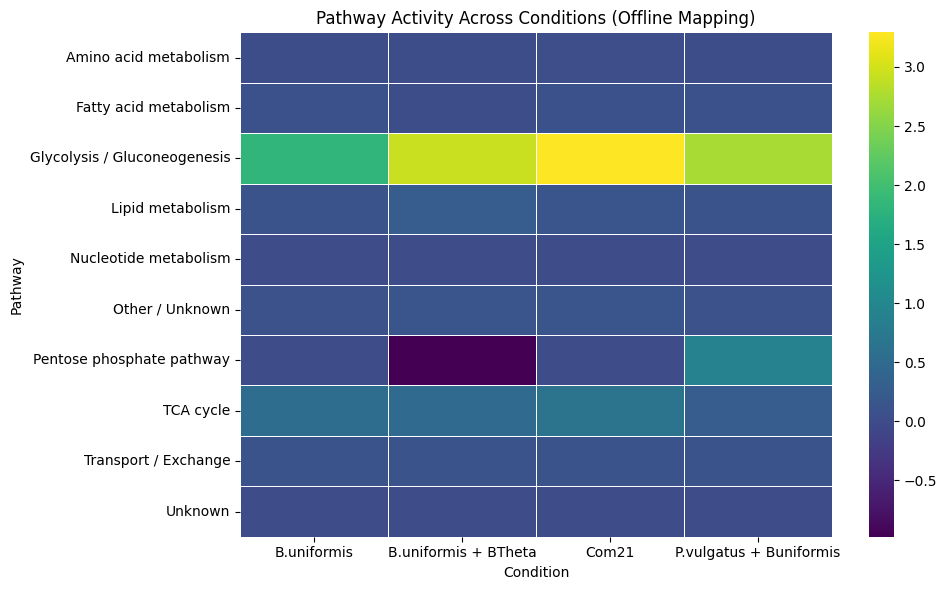

In [72]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_pathway_flux, cmap="viridis", linewidths=0.5)
plt.title("Pathway Activity Across Conditions (Offline Mapping)")
plt.xlabel("Condition")
plt.ylabel("Pathway")
plt.tight_layout()
plt.savefig("/scratch/rebernig/VR002_Model_Analysis/Output/Corneto/Flux/lambda1/Buniformis_Pathwayactivity")
plt.show()